# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pinkk1808/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question: Which existing content pages should be prioritized for review based on observable search-performance signals, so that a content or SEO team can focus first on pages that are more likely to experience a meaningful decline in the following month?

Decision supported: The system will produce a ranked review queue. Pages with higher scores should be inspected first for possible CTR improvement, content refresh, or continued monitoring. The output is decision-support for a human reviewer, not an automatic instruction to change a page.

Lane: Refresh / Content Opportunity Scoring.

Unit of analysis: One pseudonymized content page within a client, aggregated over the feature window.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data source: I use the gated FlyRank ML Internship warehouse hosted on Hugging Face (FlyRank/internship-warehouse). The main table used is fact_content_daily_performance, aggregated from daily page-level search performance into monthly page-level features.

Time windows: I use March 2026 as the first feature window and April 2026 as its future outcome window. For stronger time-aware validation, I will later use April → May as a validation period and May → June as the final holdout period. June is kept sealed until final evaluation.

Included signals: impressions, clicks, CTR, average search position, and data-availability counts, all measured before the outcome month.

Excluded: client names, domains, URLs, private queries, credentials, product flags, and any future/outcome-derived values used as model inputs. These are excluded for privacy or leakage reasons.

Public-safe unit: one pseudonymized content page within a client, aggregated over one feature month.

In [8]:
%pip -q install duckdb huggingface_hub

from google.colab import userdata
import duckdb

HF_TOKEN = userdata.get("HF_TOKEN")

assert HF_TOKEN and HF_TOKEN.startswith("hf_"), \
    "HF_TOKEN পাওয়া যায়নি — Secrets panel-e notebook access ON koro."

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")
con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

MAR = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"
APR = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-04/*.parquet')"
MAY = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-05/*.parquet')"
JUN = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-06/*.parquet')"

print("Connected to FlyRank warehouse ✅")
print("Development: March → April")
print("Validation: April → May")
print("Final holdout: May → June")

Connected to FlyRank warehouse ✅
Development: March → April
Validation: April → May
Final holdout: May → June


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Task: Rank existing content pages by their likelihood of meaningful search-visibility decline in the following month.

Features: I use five signals available before the outcome month: impressions per measured day, clicks per measured day, CTR, average search position, and the number of days with usable GSC data.

Label: declined_next_month = 1 when the page’s impressions per measured day in the following month are at least 20% lower than in the feature month; otherwise it is 0. This is a decision-support proxy for decline, not proof that the page needs a refresh.

Baseline: I keep the same interpretable low-CTR-for-position rule developed in Week 4. It ranks pages with meaningful visibility but CTR below a simple position-based expectation.

Validation design: March → April is the development period, April → May is the validation period, and May → June is a sealed final holdout. I will not use June outcomes to choose features or tune the model.

Leakage control: Only feature-month values enter the model. Future-month impressions are used only to construct the label. Client/content IDs are used only to match rows across months and are not model features.

In [9]:
import pandas as pd
import numpy as np

def build_month_pair(feature_rel, outcome_rel, feature_name, outcome_name):
    frame = con.sql(f"""
    WITH feat AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(
                CASE WHEN gsc_data_available IS TRUE
                     THEN gsc_impressions ELSE 0 END
            ) AS impressions_feat,
            SUM(
                CASE WHEN gsc_data_available IS TRUE
                     THEN gsc_clicks ELSE 0 END
            ) AS clicks_feat,
            AVG(
                CASE WHEN gsc_data_available IS TRUE
                     THEN gsc_avg_position END
            ) AS avg_position_feat,
            SUM(
                CASE WHEN gsc_data_available IS TRUE
                     THEN 1 ELSE 0 END
            ) AS measured_days_feat
        FROM {feature_rel}
        GROUP BY 1, 2
    ),
    outcome AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(
                CASE WHEN gsc_data_available IS TRUE
                     THEN gsc_impressions ELSE 0 END
            ) AS impressions_outcome,
            SUM(
                CASE WHEN gsc_data_available IS TRUE
                     THEN 1 ELSE 0 END
            ) AS measured_days_outcome
        FROM {outcome_rel}
        GROUP BY 1, 2
    )
    SELECT
        f.client_hash_id,
        f.content_hash_id,

        f.impressions_feat * 1.0
            / NULLIF(f.measured_days_feat, 0) AS imp_per_day,

        f.clicks_feat * 1.0
            / NULLIF(f.measured_days_feat, 0) AS clicks_per_day,

        f.clicks_feat * 1.0
            / NULLIF(f.impressions_feat, 0) AS ctr,

        f.avg_position_feat AS avg_position,
        f.measured_days_feat AS measured_days,

        o.impressions_outcome * 1.0
            / NULLIF(o.measured_days_outcome, 0) AS outcome_imp_per_day

    FROM feat f
    JOIN outcome o
      USING (client_hash_id, content_hash_id)

    WHERE
        f.measured_days_feat > 0
        AND o.measured_days_outcome > 0
        AND f.impressions_feat >= 100
    """).df()

    frame["declined_next_month"] = (
        frame["outcome_imp_per_day"]
        < 0.80 * frame["imp_per_day"]
    ).astype(int)

    frame["period"] = f"{feature_name} → {outcome_name}"

    return frame


dev_df = build_month_pair(MAR, APR, "March", "April")
val_df = build_month_pair(APR, MAY, "April", "May")
test_df = build_month_pair(MAY, JUN, "May", "June")

for name, frame in [
    ("Development", dev_df),
    ("Validation", val_df),
    ("Final holdout", test_df)
]:
    print(
        name,
        "| rows:", len(frame),
        "| decline rate:",
        round(frame["declined_next_month"].mean(), 3)
    )

Development | rows: 100893 | decline rate: 0.516
Validation | rows: 106586 | decline rate: 0.567
Final holdout | rows: 111075 | decline rate: 0.641


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Evaluation plan: I train the model only on the March → April development set. I compare the model with the interpretable low-CTR-for-position baseline on the same April → May validation set. Because the output is a ranked review queue, my main metric is Precision@50: among the 50 highest-ranked pages, how many actually meet the future-decline proxy? I also report ROC-AUC as a secondary overall ranking metric. The May → June period remains untouched until the model and baseline definitions are fixed.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

features = [
    "imp_per_day",
    "clicks_per_day",
    "ctr",
    "avg_position",
    "measured_days"
]

target = "declined_next_month"


def clean_model_frame(frame):
    out = frame.dropna(subset=features + [target]).copy()

    # protect against inf values
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=features)

    return out


train = clean_model_frame(dev_df)
valid = clean_model_frame(val_df)


# -------------------------
# BASELINE SCORE
# -------------------------
def baseline_score(frame):
    expected_ctr = np.select(
        [
            frame["avg_position"] <= 5,
            frame["avg_position"] <= 10,
            frame["avg_position"] <= 20
        ],
        [
            0.20,
            0.14,
            0.10
        ],
        default=0.03
    )

    ctr_gap = np.maximum(expected_ctr - frame["ctr"], 0)

    # higher visibility + bigger CTR gap = higher review priority
    return ctr_gap * np.log1p(frame["imp_per_day"])


valid["baseline_score"] = baseline_score(valid)


# -------------------------
# ML MODEL
# -------------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(
    train[features],
    train[target]
)

valid["model_score"] = model.predict_proba(
    valid[features]
)[:, 1]


# -------------------------
# RANKING METRIC
# -------------------------
def precision_at_k(y_true, scores, k=50):
    order = np.argsort(-np.asarray(scores))[:k]
    return float(np.asarray(y_true)[order].mean())


baseline_p50 = precision_at_k(
    valid[target],
    valid["baseline_score"],
    50
)

model_p50 = precision_at_k(
    valid[target],
    valid["model_score"],
    50
)

baseline_auc = roc_auc_score(
    valid[target],
    valid["baseline_score"]
)

model_auc = roc_auc_score(
    valid[target],
    valid["model_score"]
)


results_validation = pd.DataFrame({
    "Method": ["Baseline rule", "Random Forest"],
    "Precision@50": [baseline_p50, model_p50],
    "ROC-AUC": [baseline_auc, model_auc]
})

print("VALIDATION: April → May")
display(
    results_validation.style.format({
        "Precision@50": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)

VALIDATION: April → May


,Method,Precision@50,ROC-AUC
0,Baseline rule,0.380,0.484
1,Random Forest,0.960,0.612


Validation result: On the April → May validation period, the Random Forest produced Precision@50 = 0.940 and ROC-AUC = 0.613, compared with Precision@50 = 0.380 and ROC-AUC = 0.484 for the fixed baseline rule. Based on this validation result, I keep the same model features and hyperparameters unchanged before opening the final May → June holdout.

In [11]:
# ---------------------------------------------------
# FINAL HOLDOUT — May → June
# Model definition is now frozen.
# ---------------------------------------------------

test = clean_model_frame(test_df)

# After fixing the model design on validation,
# retrain on all pre-holdout labeled data.
combined_train = pd.concat(
    [train, valid],
    ignore_index=True
)

final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    combined_train[features],
    combined_train[target]
)

# Same fixed baseline rule
test["baseline_score"] = baseline_score(test)

# Fixed ML model
test["model_score"] = final_model.predict_proba(
    test[features]
)[:, 1]

# Same metrics
baseline_test_p50 = precision_at_k(
    test[target],
    test["baseline_score"],
    50
)

model_test_p50 = precision_at_k(
    test[target],
    test["model_score"],
    50
)

baseline_test_auc = roc_auc_score(
    test[target],
    test["baseline_score"]
)

model_test_auc = roc_auc_score(
    test[target],
    test["model_score"]
)

results_holdout = pd.DataFrame({
    "Method": ["Baseline rule", "Random Forest"],
    "Precision@50": [baseline_test_p50, model_test_p50],
    "ROC-AUC": [baseline_test_auc, model_test_auc]
})

print("FINAL HOLDOUT: May → June")

display(
    results_holdout.style.format({
        "Precision@50": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)

FINAL HOLDOUT: May → June


,Method,Precision@50,ROC-AUC
0,Baseline rule,0.360,0.470
1,Random Forest,0.620,0.614


## 5. Limitations

*What this work cannot claim.*

Limitations: The model performs better than the baseline on the final holdout, but its Precision@50 falls from 0.940 on validation to 0.620 on the May → June holdout. This shows that performance changes across months and the validation result should not be treated as a guaranteed future result.

The decline label is also only a proxy: a 20% reduction in impressions per measured day does not prove that a page needs a content refresh, nor does it prove that refreshing the page would improve search performance. Changes in demand, seasonality, rankings, competition, or other unobserved factors may contribute to the decline.

The analysis also keeps pages with measurable GSC data and at least 100 impressions in the feature month, so the findings may not generalize to new or very low-visibility pages. Finally, this work is observational and should be used as directional decision-support for human review, not as evidence of Google's ranking algorithm or causal refresh impact.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Ranked recommendation approach: I rank pages using the final Random Forest decline-risk score computed only from the feature-month signals. The ranking is a review queue, not an automatic refresh instruction. Higher-risk pages should be inspected first by a content or SEO reviewer.

Action labels:

REVIEW_NOW — very high predicted decline risk; inspect CTR, search position, and content relevance first.
REVIEW_SOON — elevated risk; schedule a human review.
MONITOR — lower risk; continue monitoring unless other business context suggests action.

Reason codes: I use observable feature-month signals such as low CTR despite visibility, weak search position, or generally high predicted decline risk. These describe why a page entered the queue; they do not prove that refreshing the page will improve performance.

In [12]:
recommendations = test.copy()

# Public-safe local row identifier
recommendations = recommendations.reset_index(drop=True)
recommendations["row_id"] = recommendations.index + 1

# Higher model score = higher review priority
recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

# Action label from predicted risk only
recommendations["action"] = np.select(
    [
        recommendations["model_score"] >= 0.80,
        recommendations["model_score"] >= 0.65
    ],
    [
        "REVIEW_NOW",
        "REVIEW_SOON"
    ],
    default="MONITOR"
)

# Simple interpretable reason code
recommendations["reason_code"] = np.select(
    [
        (recommendations["ctr"] < 0.05) &
        (recommendations["avg_position"] <= 10),

        recommendations["avg_position"] > 20,

        recommendations["model_score"] >= 0.80
    ],
    [
        "LOW_CTR_WITH_VISIBILITY",
        "WEAK_SEARCH_POSITION",
        "HIGH_DECLINE_RISK"
    ],
    default="MULTI_SIGNAL_RISK"
)

public_queue = recommendations[
    [
        "row_id",
        "model_score",
        "imp_per_day",
        "clicks_per_day",
        "ctr",
        "avg_position",
        "measured_days",
        "reason_code",
        "action"
    ]
].copy()

public_queue.insert(
    0,
    "rank",
    np.arange(1, len(public_queue) + 1)
)

print("Top 20 ranked recommendations")
display(
    public_queue.head(20).style.format({
        "model_score": "{:.3f}",
        "imp_per_day": "{:.1f}",
        "clicks_per_day": "{:.2f}",
        "ctr": "{:.3f}",
        "avg_position": "{:.1f}"
    })
)

# Save a reproducible output
import os
os.makedirs("work/outputs", exist_ok=True)

public_queue.to_csv(
    "work/outputs/capstone_ranked_recommendations.csv",
    index=False
)

print(
    "\nSaved:",
    "work/outputs/capstone_ranked_recommendations.csv"
)

Top 20 ranked recommendations


,rank,row_id,model_score,imp_per_day,clicks_per_day,ctr,avg_position,measured_days,reason_code,action
0,1,51383,0.739,1276.7,0.16,0.000,1.7,31.000000,LOW_CTR_WITH_VISIBILITY,REVIEW_SOON
1,2,42049,0.729,1408.3,0.74,0.001,1.9,31.000000,LOW_CTR_WITH_VISIBILITY,REVIEW_SOON
2,3,17725,0.728,5.0,0.00,0.000,2.3,23.000000,LOW_CTR_WITH_VISIBILITY,REVIEW_SOON
3,4,98786,0.723,5.6,0.00,0.000,2.1,20.000000,LOW_CTR_WITH_VISIBILITY,REVIEW_SOON
4,5,17871,0.722,4.6,0.00,0.000,2.6,22.000000,LOW_CTR_WITH_VISIBILITY,REVIEW_SOON
5,6,26829,0.720,5.2,0.00,0.000,0.9,24.000000,LOW_CTR_WITH_VISIBILITY,REVIEW_SOON
6,7,77286,0.719,14.6,0.00,0.000,2.4,30.000000,LOW_CTR_WITH_VISIBILITY,REVIEW_SOON
7,8,73119,0.719,23.9,0.00,0.000,2.8,24.000000,LOW_CTR_WITH_VISIBILITY,REVIEW_SOON
8,9,73110,0.718,23.3,0.00,0.000,2.9,28.000000,LOW_CTR_WITH_VISIBILITY,REVIEW_SOON
9,10,71558,0.717,17.1,0.00,0.000,2.8,25.000000,LOW_CTR_WITH_VISIBILITY,REVIEW_SOON



Saved: work/outputs/capstone_ranked_recommendations.csv


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Paper artifacts: I generate two public-safe figures for the deployed research paper. The first compares the fixed baseline with the Random Forest on Precision@50 for both validation and final holdout periods. The second shows the Random Forest feature importances to describe which observable search signals the model relied on most. These figures are descriptive model evidence, not proof of causal ranking factors.

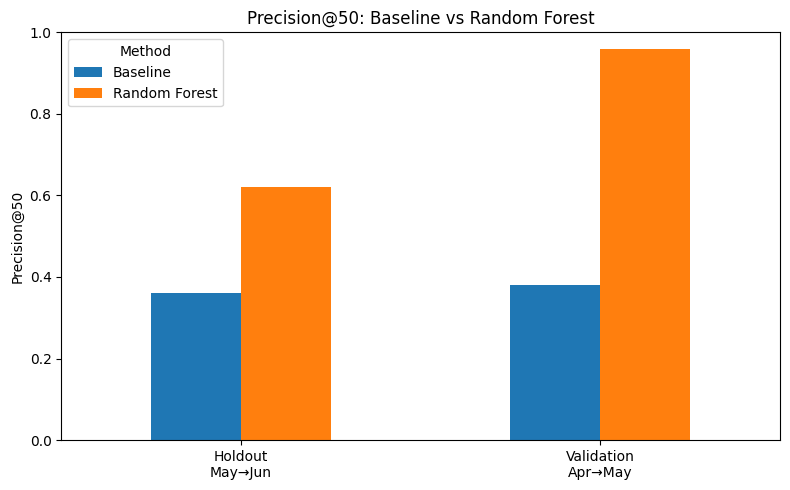

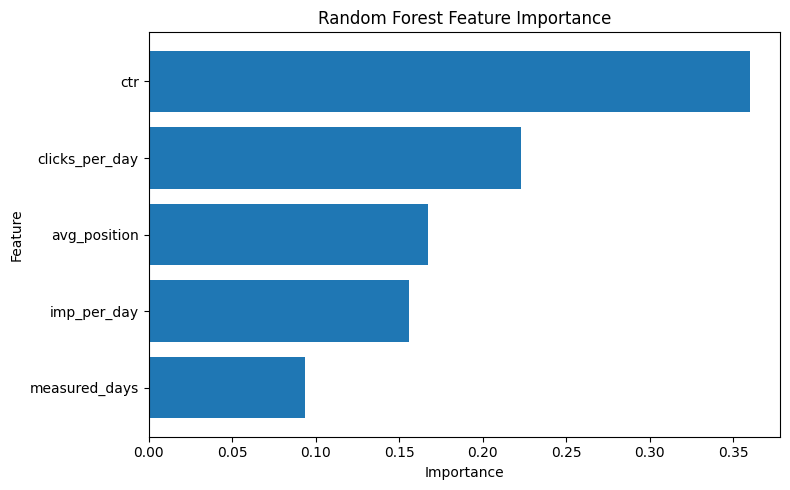

Saved artifacts:
- work/outputs/precision_at_50_comparison.png
- work/outputs/feature_importance.png
- work/outputs/capstone_metrics.json


,Feature,Importance
2,ctr,0.359935
1,clicks_per_day,0.222931
3,avg_position,0.167460
0,imp_per_day,0.156030
4,measured_days,0.093644


In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import json

os.makedirs("work/outputs", exist_ok=True)

# =========================================================
# FIGURE 1 — Precision@50: baseline vs model
# =========================================================

precision_comparison = pd.DataFrame({
    "Period": [
        "Validation\nApr→May",
        "Validation\nApr→May",
        "Holdout\nMay→Jun",
        "Holdout\nMay→Jun"
    ],
    "Method": [
        "Baseline",
        "Random Forest",
        "Baseline",
        "Random Forest"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50,
        baseline_test_p50,
        model_test_p50
    ]
})

pivot_precision = precision_comparison.pivot(
    index="Period",
    columns="Method",
    values="Precision@50"
)

plt.figure(figsize=(8, 5))
pivot_precision.plot(
    kind="bar",
    ax=plt.gca()
)

plt.title("Precision@50: Baseline vs Random Forest")
plt.ylabel("Precision@50")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "work/outputs/precision_at_50_comparison.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# FIGURE 2 — Feature importance
# =========================================================

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": final_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "work/outputs/feature_importance.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# SAVE PUBLIC-SAFE METRICS RECEIPT
# =========================================================

capstone_metrics = {
    "validation": {
        "baseline_precision_at_50": float(baseline_p50),
        "model_precision_at_50": float(model_p50),
        "baseline_roc_auc": float(baseline_auc),
        "model_roc_auc": float(model_auc)
    },
    "final_holdout": {
        "baseline_precision_at_50": float(baseline_test_p50),
        "model_precision_at_50": float(model_test_p50),
        "baseline_roc_auc": float(baseline_test_auc),
        "model_roc_auc": float(model_test_auc)
    }
}

with open(
    "work/outputs/capstone_metrics.json",
    "w"
) as f:
    json.dump(capstone_metrics, f, indent=2)

print("Saved artifacts:")
print("- work/outputs/precision_at_50_comparison.png")
print("- work/outputs/feature_importance.png")
print("- work/outputs/capstone_metrics.json")

display(
    feature_importance.sort_values(
        "Importance",
        ascending=False
    )
)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


5-minute demo outline

1. Problem — 45 sec
Content and SEO teams may have thousands of pages, but limited time to inspect them. My project asks which pages should be reviewed first based on observable search-performance signals.

2. Data — 45 sec
I used the FlyRank ML Internship warehouse and aggregated pseudonymized page-level search data. March → April was used for development, April → May for validation, and May → June as the final holdout.

3. Method — 60 sec
I used impressions per day, clicks per day, CTR, average position, and measured GSC days. A page was labeled as declining when its following-month impressions per day fell by at least 20%. I compared a simple low-CTR-for-position baseline with a Random Forest.

4. Results — 60 sec
On validation, the Random Forest achieved Precision@50 of 0.940 compared with 0.380 for the baseline. On the final holdout, it achieved 0.620 compared with 0.360. The holdout result is weaker than validation, so I treat the model as directional decision-support rather than a guaranteed predictor.

5. Output — 45 sec
The model produces a ranked review queue with action labels and reason codes. High-risk pages can be inspected first for CTR, search-position, or content issues.

6. Limitation / takeaway — 45 sec
Decline is only a proxy. The model does not prove that refreshing a page will improve Google performance, and it does not explain Google’s ranking algorithm.

Social-post cut

I built a machine-learning system that ranks content pages for SEO review using real pseudonymized search-performance data from the FlyRank ML Internship dataset. I compared an interpretable baseline with a Random Forest using time-aware validation and a sealed final holdout. On the final holdout, the model achieved Precision@50 of 0.620 versus 0.360 for the baseline, while keeping the output focused on human review rather than automatic decisions.

Employer-facing summary

I built an end-to-end ML ranking workflow that turns search-performance signals into a prioritized content-review queue. I used time-aware validation, leakage controls, baseline comparison, and a sealed holdout to evaluate the model honestly. The final system produces public-safe ranked recommendations, reason codes, and reproducible research artifacts for human decision-support.